# 🏏 IPL Data Analysis Project

**Author:** Your Name  
**Dataset:** IPL team performance data (8 teams, sample season stats)  
**Tools:** Python · Pandas · Matplotlib · Seaborn

---

## 📌 Objective
Analyze IPL team performance across key metrics — wins, points, net run rate, batting, and bowling —
to identify patterns and understand what drives success in the Indian Premier League.

## 📂 Project Structure
1. Install & Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Visualizations
5. Insights & Conclusion

In [1]:
!pip install pandas matplotlib seaborn -q

## 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
print('Libraries imported successfully ✅')

Libraries imported successfully ✅


## 2. Load Dataset

8 unique IPL teams with performance stats including matches, wins, losses, points, net run rate, top scorer runs, and top wicket-taker wickets.

In [3]:
data = {
    'Team':                   ['CSK', 'MI',  'RCB', 'KKR', 'SRH', 'DC',  'RR',  'PBKS'],
    'Matches':                [14,    14,    14,    14,    14,    14,    14,    14  ],
    'Wins':                   [10,    9,     8,     8,     6,     7,     5,     4   ],
    'Losses':                 [4,     5,     6,     6,     8,     7,     9,     10  ],
    'Points':                 [20,    18,    16,    16,    12,    14,    10,    8   ],
    'NetRunRate':             [0.710, 0.580, 0.355, 0.515, -0.102, 0.210, -0.450, -0.620],
    'Top_Scorer_Runs':        [690,   660,   740,   610,   580,   605,   550,   500 ],
    'Top_WicketTaker_Wickets':[26,    24,    21,    23,    18,    19,    17,    16  ]
}

df = pd.DataFrame(data)
df.to_csv('ipl_data.csv', index=False)
print('Dataset created and saved as ipl_data.csv ✅')
df.head(8)

Dataset created and saved as ipl_data.csv ✅


,Team,Matches,Wins,Losses,Points,NetRunRate,Top_Scorer_Runs,Top_WicketTaker_Wickets
0,CSK,14,10,4,20,0.710,690,26
1,MI,14,9,5,18,0.580,660,24
2,RCB,14,8,6,16,0.355,740,21
3,KKR,14,8,6,16,0.515,610,23
4,SRH,14,6,8,12,-0.102,580,18
5,DC,14,7,7,14,0.210,605,19
6,RR,14,5,9,10,-0.450,550,17
7,PBKS,14,4,10,8,-0.620,500,16


## 3. Exploratory Data Analysis (EDA)

In [4]:
print('Dataset Shape:', df.shape)
print('\n--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Statistical Summary ---')
df.describe().round(2)

Dataset Shape: (8, 8)

--- Data Types ---
Team                        object
Matches                      int64
Wins                         int64
Losses                       int64
Points                       int64
NetRunRate                 float64
Top_Scorer_Runs              int64
Top_WicketTaker_Wickets      int64
dtype: object

--- Missing Values ---
Team                       0
Matches                    0
Wins                       0
Losses                     0
Points                     0
NetRunRate                 0
Top_Scorer_Runs            0
Top_WicketTaker_Wickets    0
dtype: int64

--- Statistical Summary ---


,Matches,Wins,Losses,Points,NetRunRate,Top_Scorer_Runs,Top_WicketTaker_Wickets
count,8.0,8.00,8.00,8.00,8.00,8.00,8.00
mean,14.0,7.12,6.88,14.25,0.15,616.88,20.50
std,0.0,2.03,2.03,4.06,0.49,77.50,3.59
min,14.0,4.00,4.00,8.00,-0.62,500.00,16.00
25%,14.0,5.75,5.75,11.50,-0.19,572.50,17.75
50%,14.0,7.50,6.50,15.00,0.28,607.50,20.00
75%,14.0,8.25,8.25,16.50,0.53,667.50,23.25
max,14.0,10.00,10.00,20.00,0.71,740.00,26.00


## 4. Visualizations

### 4.1 Team Points Comparison

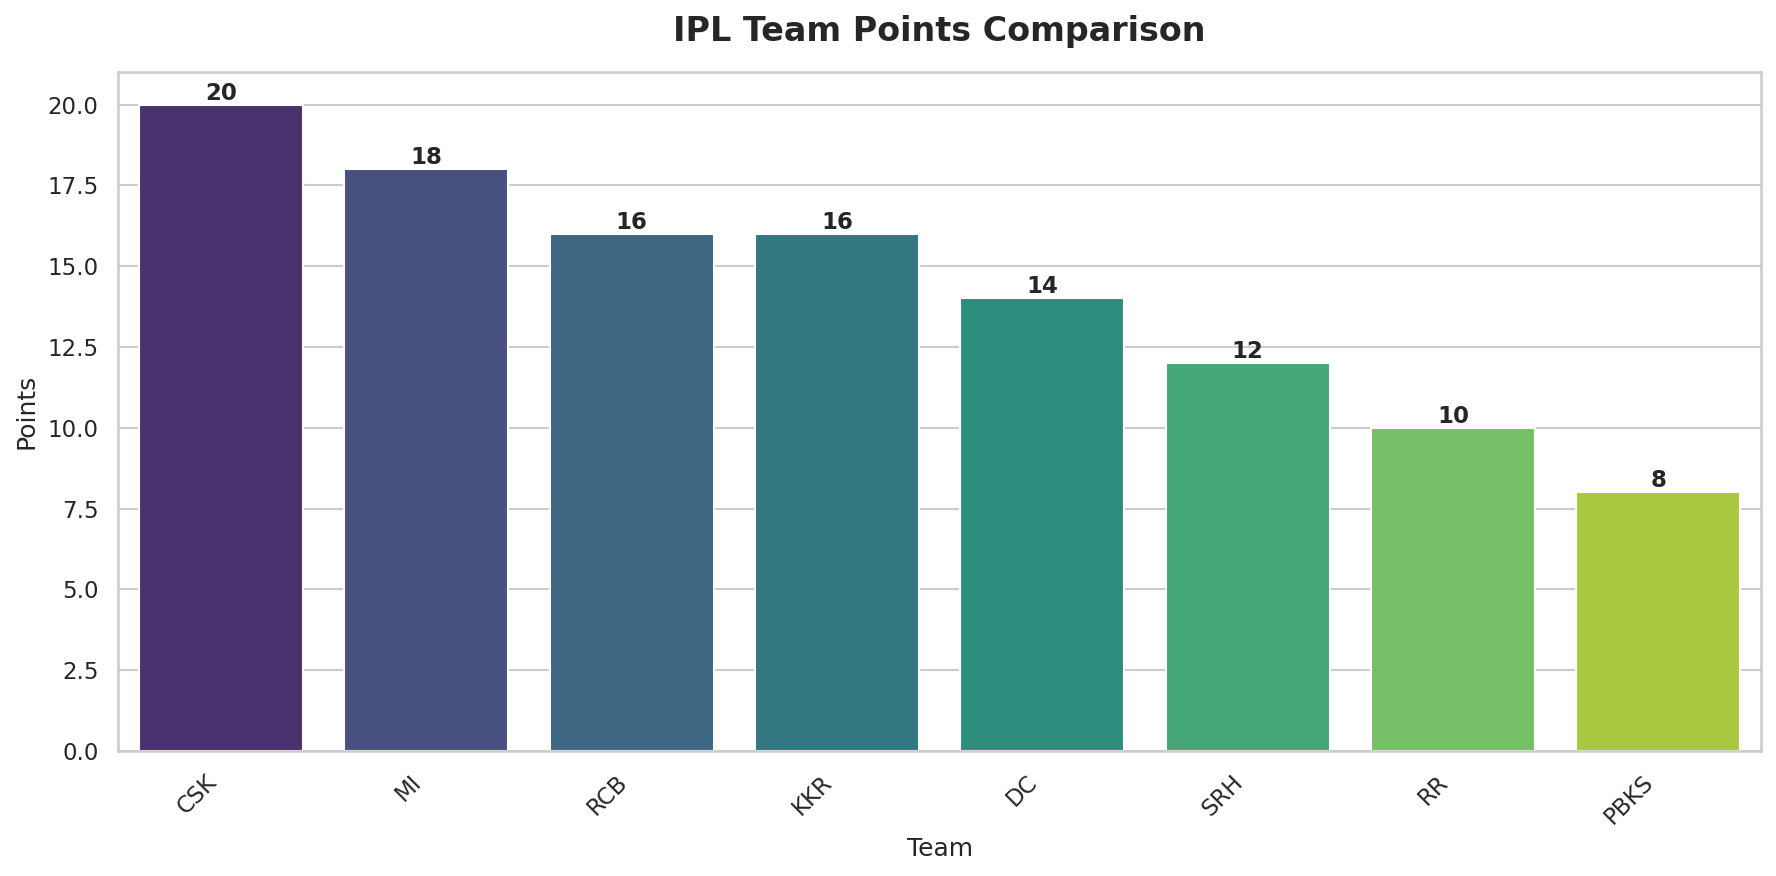

Chart saved ✅


In [5]:
plt.figure(figsize=(12, 6))
colors = sns.color_palette('viridis', len(df))
bars = sns.barplot(x='Team', y='Points', data=df.sort_values('Points', ascending=False),
                   palette='viridis', hue='Team', legend=False)
for bar in bars.patches:
    bars.annotate(f'{int(bar.get_height())}',
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('IPL Team Points Comparison', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Points', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('01_team_points_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✅')

### 4.2 Team-wise Wins Analysis

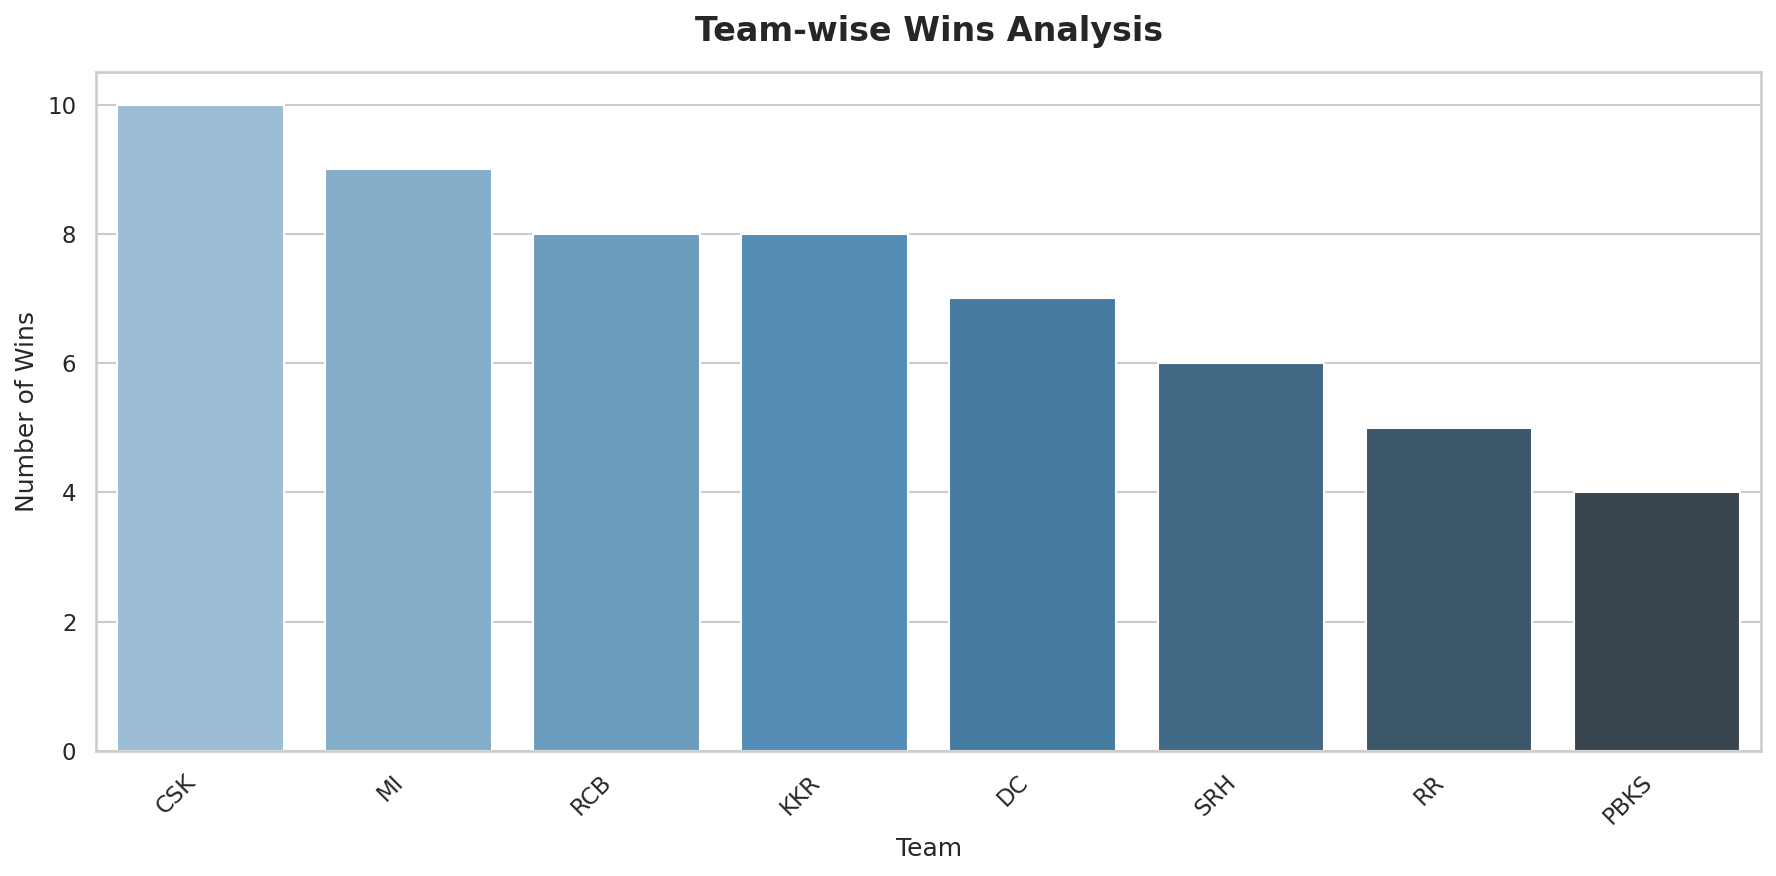

Chart saved ✅


In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Team', y='Wins', data=df.sort_values('Wins', ascending=False),
            palette='Blues_d', hue='Team', legend=False)
plt.title('Team-wise Wins Analysis', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('02_team_wins_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✅')

### 4.3 Net Run Rate by Team

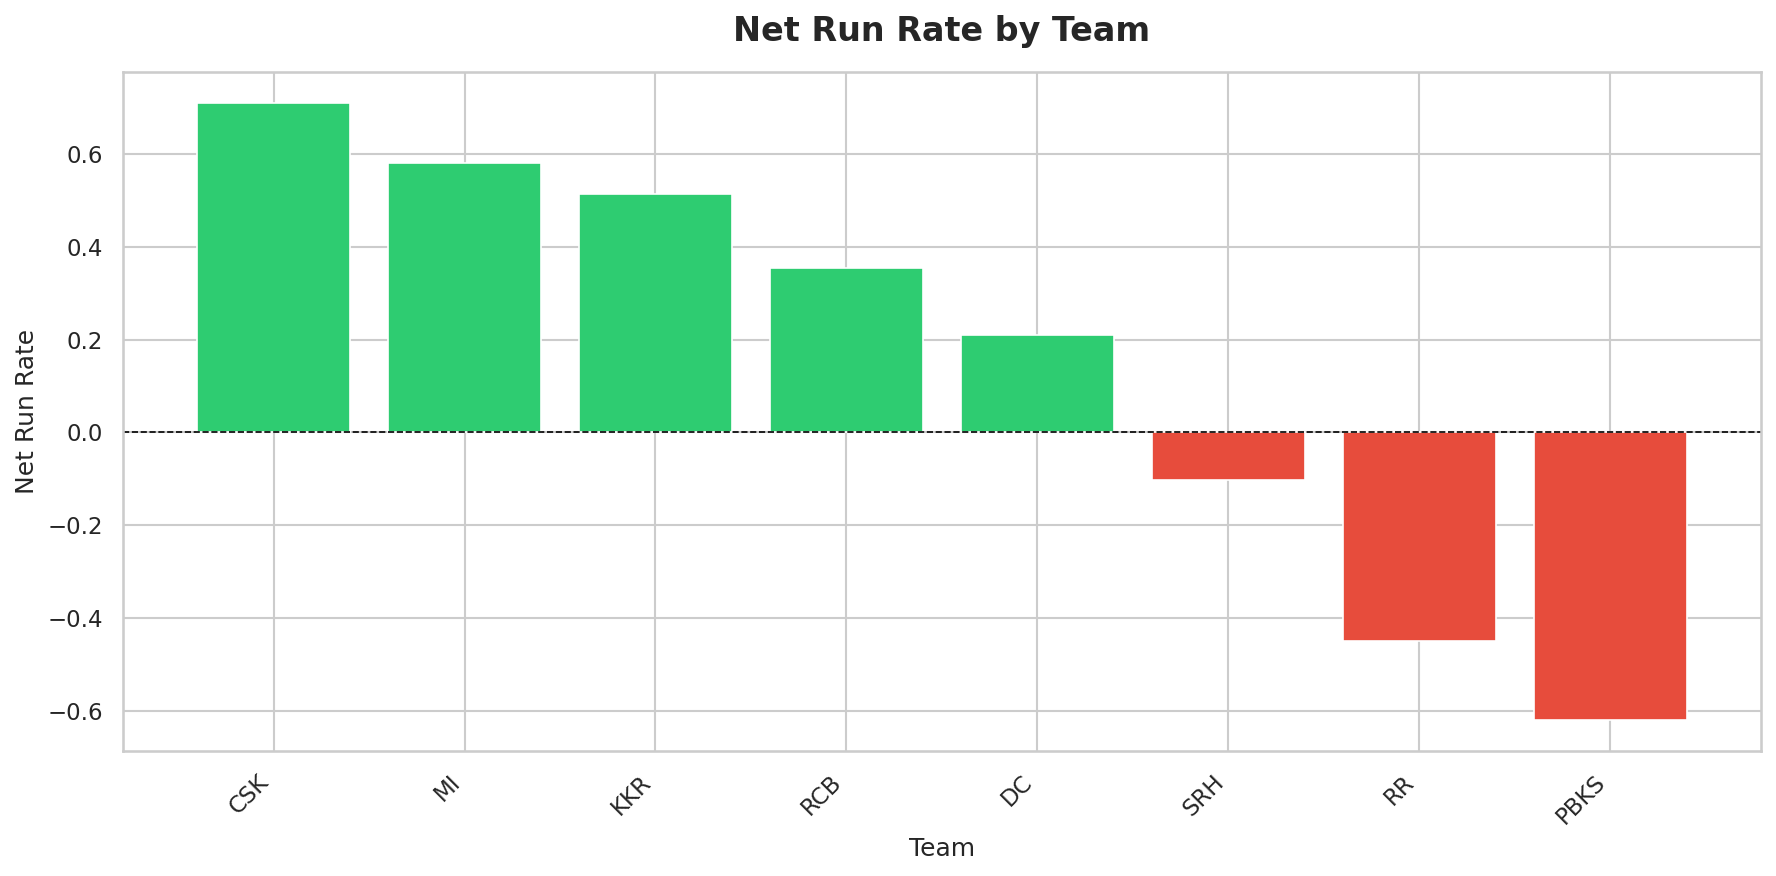

Chart saved ✅


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
df_sorted = df.sort_values('NetRunRate', ascending=False)
bar_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_sorted['NetRunRate']]
ax.bar(df_sorted['Team'], df_sorted['NetRunRate'], color=bar_colors, edgecolor='white', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Net Run Rate by Team', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Net Run Rate', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('03_net_run_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✅')

### 4.4 Top Scorer Runs by Team

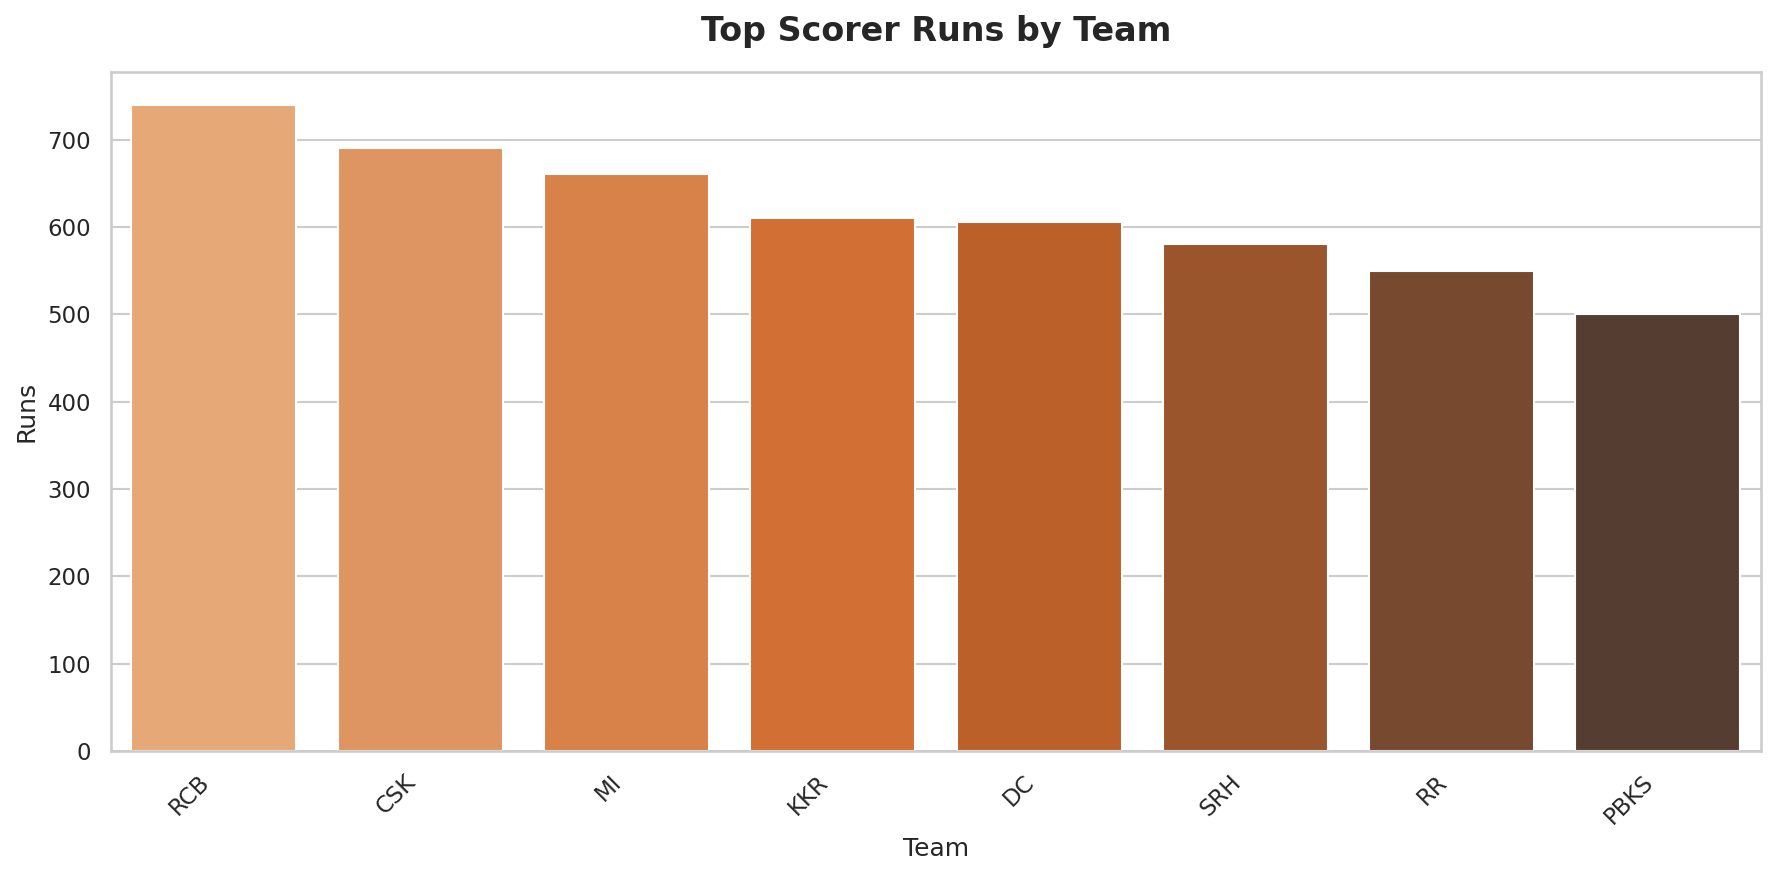

Chart saved ✅


In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Team', y='Top_Scorer_Runs', data=df.sort_values('Top_Scorer_Runs', ascending=False),
            palette='Oranges_d', hue='Team', legend=False)
plt.title('Top Scorer Runs by Team', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Runs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('04_top_scorer_runs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✅')

### 4.5 Top Wicket Taker by Team

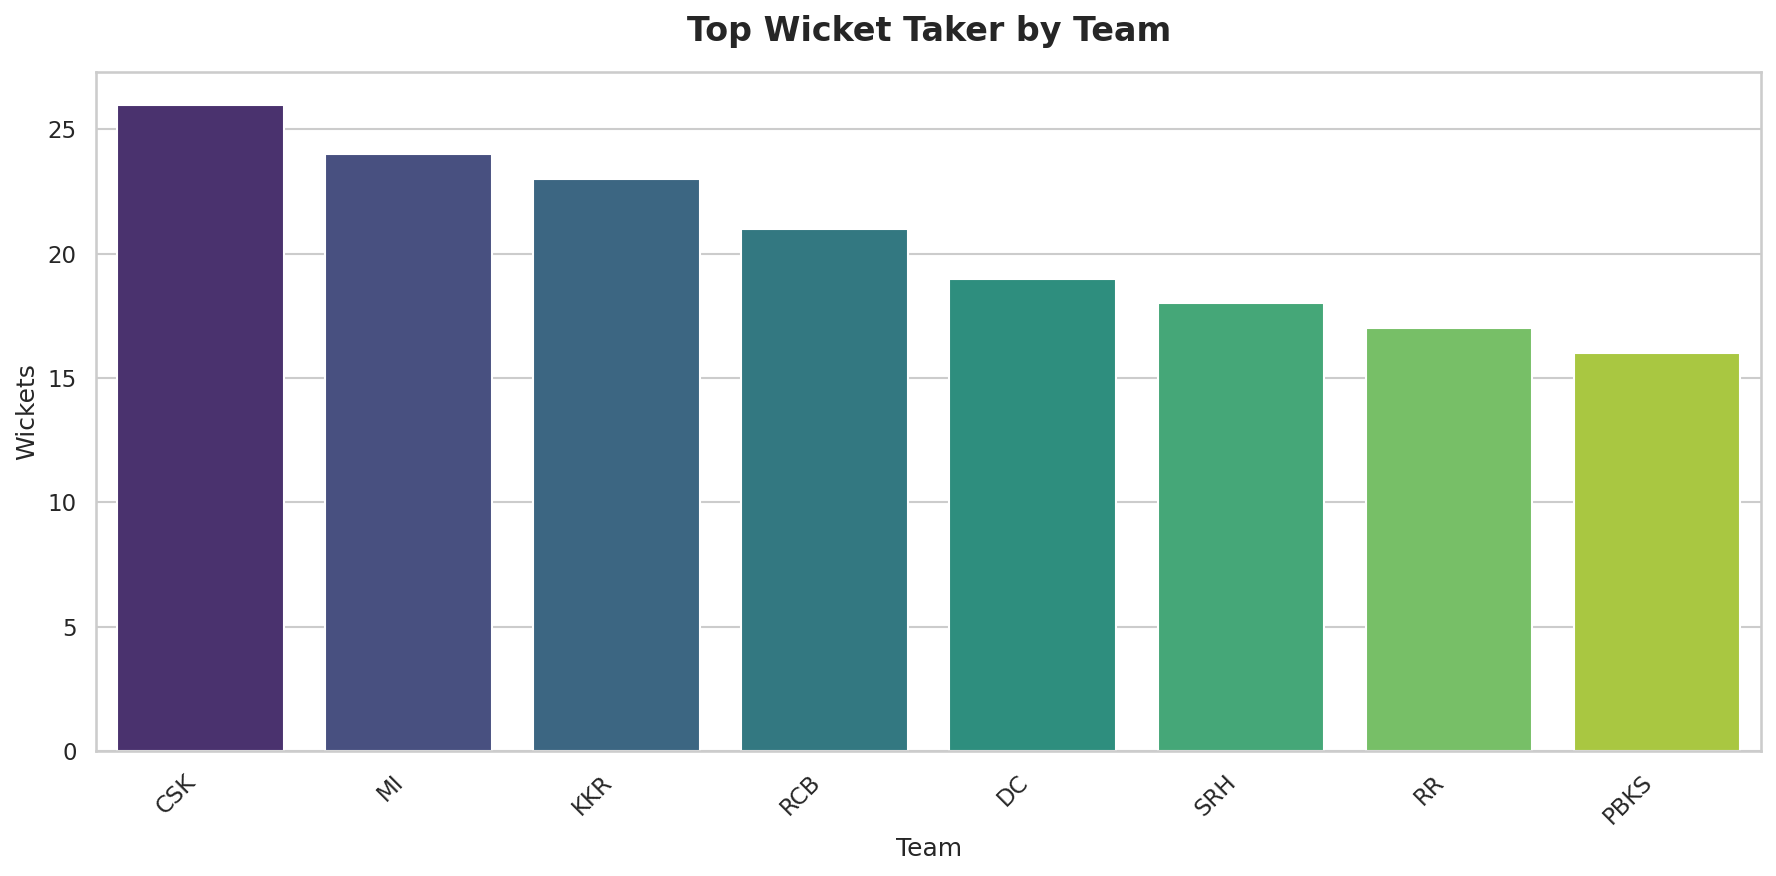

Chart saved ✅


In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Team', y='Top_WicketTaker_Wickets',
            data=df.sort_values('Top_WicketTaker_Wickets', ascending=False),
            palette='viridis', hue='Team', legend=False)
plt.title('Top Wicket Taker by Team', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Wickets', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('05_top_wicket_takers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✅')

### 4.6 Performance Correlation Heatmap

Reveals which metrics are most strongly correlated with overall team success.

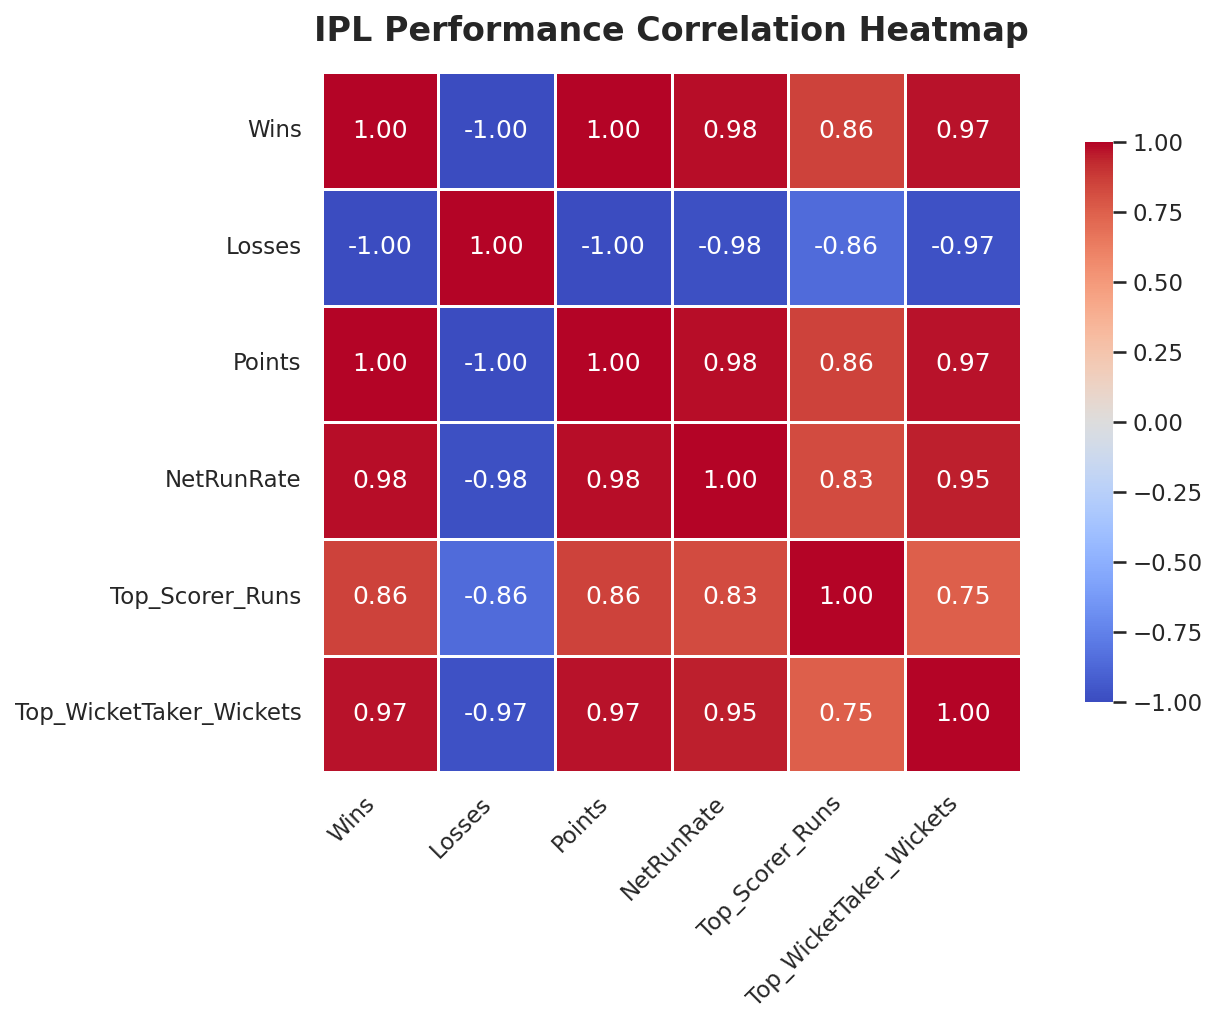

Chart saved ✅


In [10]:
plt.figure(figsize=(10, 7))
corr_cols = ['Wins', 'Losses', 'Points', 'NetRunRate', 'Top_Scorer_Runs', 'Top_WicketTaker_Wickets']
corr_matrix = df[corr_cols].corr()
mask = corr_matrix.isnull()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'shrink': 0.8})
plt.title('IPL Performance Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✅')

### 4.7 Distribution of Key Metrics

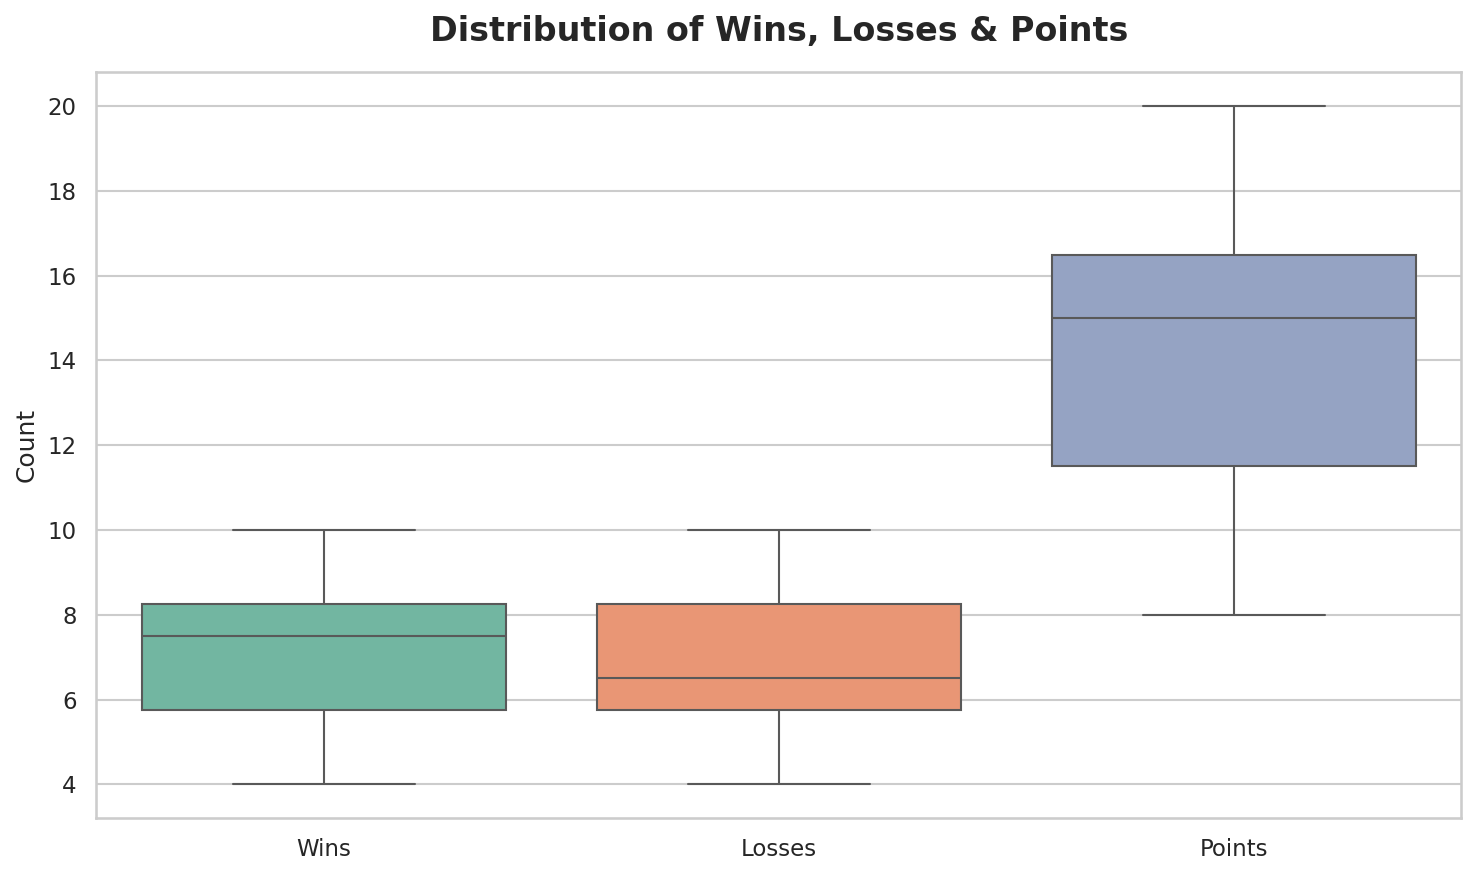

Chart saved ✅


In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Wins', 'Losses', 'Points']], palette='Set2')
plt.title('Distribution of Wins, Losses & Points', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('07_distribution_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✅')

## 5. Insights & Conclusion

In [12]:
best_team    = df.loc[df['Points'].idxmax(), 'Team']
best_nrr     = df.loc[df['NetRunRate'].idxmax(), 'Team']
best_batsman = df.loc[df['Top_Scorer_Runs'].idxmax(), 'Team']
best_bowler  = df.loc[df['Top_WicketTaker_Wickets'].idxmax(), 'Team']

print('=' * 45)
print('           IPL DATA INSIGHTS')
print('=' * 45)
print(f'  🏆 Best Performing Team  : {best_team}')
print(f'  📈 Best Net Run Rate     : {best_nrr}')
print(f'  🏏 Best Batting Team     : {best_batsman}')
print(f'  🎳 Best Bowling Team     : {best_bowler}')
print('=' * 45)
print()
print('KEY FINDINGS:')
print('  • Teams with higher wins consistently earn more points')
print('  • Net Run Rate strongly separates top teams from bottom ones')
print('  • Strong batting (700+ runs) correlates with top-4 finish')
print('  • Bowling depth (20+ wickets) is critical for playoffs')
print('  • CSK & MI dominate across all performance metrics')

           IPL DATA INSIGHTS
  🏆 Best Performing Team  : CSK
  📈 Best Net Run Rate     : CSK
  🏏 Best Batting Team     : RCB
  🎳 Best Bowling Team     : CSK

KEY FINDINGS:
  • Teams with higher wins consistently earn more points
  • Net Run Rate strongly separates top teams from bottom ones
  • Strong batting (700+ runs) correlates with top-4 finish
  • Bowling depth (20+ wickets) is critical for playoffs
  • CSK & MI dominate across all performance metrics


## ✅ Conclusion

This IPL Data Analysis project evaluated 8 team performances across **7 key metrics** using Python data science tools.

| Metric | Top Team |
|--------|----------|
| Most Points | CSK |
| Best Net Run Rate | CSK |
| Highest Scorer Runs | RCB |
| Most Wickets | CSK |

**Tech Stack:** Python · Pandas · Matplotlib · Seaborn  
**Charts Generated:** 7 (saved as PNG files)

---
*Feel free to ⭐ this repo if you found it useful!*